Loading Data Structure. To see how the following code works and what is the meaning of the imported code such import src.utils.config as config read the tutorial.ipynb file

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

import src.utils.config as config
import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()

print(data_root)
print(pdata_root)
print("Number of animals:", len(cc_data))

/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning
Number of animals: 5


In [2]:
print(cc_data.items())
print(cc_data["NML_05"]["2026_01_04"])

dict_items([('NML_04', {'2025_12_27': {'face': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/face_1440x1080_60_20251227_154519.h264', 'pupi': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/pupi_320x240_60_20251227_154519.h264', 'video': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/video_20251227_154511.h264', 'recording': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/recording_20251227_154502.mat', 'phase': 'habituation', 'path': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27'}, '2025_12_28': {'face': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/face_1440x1080_60_20251228_154642.h264', 'pupi': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/pupi_320x240_60_20251228_154642.h264', 'video': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/video_20251228_154758.h264', 'recording': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/recording_20251228_154611.mat', 'phase': 'habituation', 'path': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28'}

# In the following code we will process the cc_data variable to analyze the mat files of recording to find speed of the animal from the encoder data

We will store it in h5 or hdf5 format

the phase value is given as 1) habituation, 2) air_training, and 3) tone_air_training



"""
Tutorial: Understanding the variables inside the behavior H5 file

After processing one behavioral session, the data are saved in an H5 file.
Each H5 file contains several variables that describe timing, air stimulus,
wheel movement, speed, and trial-by-trial behavior.
"""

# -----------------------------------------------------
# 1. Timing variables
# -----------------------------------------------------

"""
fs
    Sampling rate of the DAQ recording.
    Example: if fs = 5000, the system collected 5000 samples per second.

si
    Sampling interval.
    This is the time between two consecutive samples.

    si = 1 / fs

t
    Time vector in seconds.
    This gives the time point for every sample.

tm
    Time vector in minutes.

    tm = t / 60

number_of_samples
    Total number of samples in the recording.
"""

# -----------------------------------------------------
# 2. Air stimulus variables
# -----------------------------------------------------

"""
air_raw
    Raw air signal recorded from the DAQ.

air_bin
    Binary air signal.

    0 = air OFF
    1 = air ON

Air_r
    Air rising edges.
    These are the sample indices where air turns ON.

Air_f
    Air falling edges.
    These are the sample indices where air turns OFF.

Together:

    Air_r[i] = start of air trial i
    Air_f[i] = end of air trial i
"""

# -----------------------------------------------------
# 3. Encoder / wheel variables
# -----------------------------------------------------

"""
encoderCount
    Raw encoder count signal from the wheel.
    This represents wheel position over time.

countsPerRev
    Number of encoder counts in one full wheel revolution.
    This is used to convert encoder counts into distance.
"""

# -----------------------------------------------------
# 4. Distance variables
# -----------------------------------------------------

"""
dist_net_cm
    Net distance in centimeters.
    This keeps direction.

    Forward movement increases the value.
    Backward movement can decrease the value.

dist_path_cm
    Total path distance in centimeters.
    This ignores direction.

    Forward movement increases the value.
    Backward movement also increases the value.

Simple explanation:

    dist_net_cm  = final position relative to start
    dist_path_cm = total amount of movement
"""

# -----------------------------------------------------
# 5. Speed variables
# -----------------------------------------------------

"""
speed_net_cms
    Net speed in cm/s.
    This keeps direction.

    Positive values = movement in one direction
    Negative values = movement in the opposite direction

speed_path_cms
    Path speed in cm/s.
    This ignores direction.

    It tells us how fast the animal is moving overall.

speed_window_ms
    Window size used to calculate speed.
    In this pipeline, speed is calculated using a 100 ms window.
"""

# -----------------------------------------------------
# 6. Trial-level variable
# -----------------------------------------------------

"""
trial_forward_cm
    Forward distance traveled during each air trial.

    trial_forward_cm[0] = forward distance during trial 1
    trial_forward_cm[1] = forward distance during trial 2
    trial_forward_cm[2] = forward distance during trial 3

This is useful for checking whether the animal ran enough during each air trial.
"""

# -----------------------------------------------------
# 7. Most useful variables for analysis
# -----------------------------------------------------

"""
For general locomotion analysis:

    t
    speed_path_cms
    dist_path_cm

For air trial analysis:

    Air_r
    Air_f
    air_bin
    trial_forward_cm

For synchronization and raw signal inspection:

    air_raw
    encoderCount

For time conversion:

    fs
    si
    t
    tm
"""

# -----------------------------------------------------
# 8. Simple interpretation
# -----------------------------------------------------

"""
In simple words:

The H5 file stores the processed behavior for one animal on one recording day.

It tells us:

    when the recording happened in time,
    when air turned on and off,
    how the wheel moved,
    how fast the animal moved,
    how far the animal moved,
    and how much the animal ran during each air trial.

This makes the H5 file the main processed behavior file for later analysis.
"""

In [3]:
animal = "NML_04"
date = "2026_01_04"
h5_file = pdio.behavior_h5_path(animal, date)
print(h5_file)

/mnt/pdata/Classical_Conditioning/NML_04/2026_01_04/behavior/behavior_v1.h5


In [4]:
keys = pdio.list_behavior_h5_keys(animal, date)
print(keys)

['Air_f', 'Air_r', 'air_bin', 'air_raw', 'bias', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'encoderCount', 'fs', 'number_of_samples', 'si', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 't', 'tm', 'trial_forward_cm']


In [5]:
animal = "NML_05"
date = "2026_01_04"
# Load full behavior file
b = pdio.load_behavior_h5(animal, date)
b.keys()

dict_keys(['Air_f', 'Air_r', 'air_bin', 'air_raw', 'bias', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'encoderCount', 'fs', 'number_of_samples', 'si', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 't', 'tm', 'trial_forward_cm'])

In [6]:
b["Air_edges_report"]

KeyError: 'Air_edges_report'

In [7]:
# Load selected keys (variable) from behavior file.
speed_path_cm = pdio.load_behavior_h5(
    animal,
    date,
    keys="speed_path_cms"
)

speed_path_cm

{'speed_path_cms': array([1.00530965, 1.00530965, 1.00530965, ..., 0.        , 0.        ,
        0.        ])}

Below I am going to start actual processing of the data, looking at different aspects of speed and its relationship with habituation phase, air-training phase


In [11]:
import src.proc.behavior_metrics as bm

hab_state_0cms = bm.summarize_habituation_locomotor_states_from_h5(
    cc_data,
    speed_thresh=0.0
)

hab_state_0cms.head()



Processing animal: NML_04
Found 16 habituation sessions
[NML_04] Session 1/16 Date: 2025_12_27
Loaded keys: ['speed_net_cms', 'speed_path_cms', 'dist_path_cm', 'dist_net_cm']
Computed locomotor states: 6554000 valid samples
[NML_04] Session 2/16 Date: 2025_12_28
Loaded keys: ['speed_net_cms', 'speed_path_cms', 'dist_path_cm', 'dist_net_cm']
Computed locomotor states: 7367000 valid samples
[NML_04] Session 3/16 Date: 2025_12_29
Loaded keys: ['speed_net_cms', 'speed_path_cms', 'dist_path_cm', 'dist_net_cm']
Computed locomotor states: 6272500 valid samples
[NML_04] Session 4/16 Date: 2025_12_30
Loaded keys: ['speed_net_cms', 'speed_path_cms', 'dist_path_cm', 'dist_net_cm']
Computed locomotor states: 8121000 valid samples
[NML_04] Session 5/16 Date: 2025_12_31
Loaded keys: ['speed_net_cms', 'speed_path_cms', 'dist_path_cm', 'dist_net_cm']
Computed locomotor states: 6633000 valid samples
[NML_04] Session 6/16 Date: 2026_01_01
Loaded keys: ['speed_net_cms', 'speed_path_cms', 'dist_path_cm',

KeyboardInterrupt: 

In [10]:
import matplotlib.pyplot as plt

state_cols = [
    "frac_stationary",
    "frac_forward",
    "frac_backward",
    "frac_low_net_movement"
]

df = hab_state_0cms.copy()

mean_by_day = (
    df.groupby("normalized_day")[state_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for col in state_cols:
    plt.plot(mean_by_day["normalized_day"], mean_by_day[col], marker="o", label=col)

plt.xlabel("Normalized habituation day")
plt.ylabel("Fraction of session")
plt.title("Habituation locomotor-state distribution")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'hab_state_0cms' is not defined

In [25]:
import statsmodels.formula.api as smf


def logit_clip(p, eps=1e-4):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


df = hab_state_0cms.copy()

df["logit_frac_moving"] = logit_clip(df["frac_moving"])
df["logit_frac_forward"] = logit_clip(df["frac_forward"])
df["logit_frac_backward"] = logit_clip(df["frac_backward"])
df["logit_frac_stationary"] = logit_clip(df["frac_stationary"])


model_moving = smf.mixedlm(
    "logit_frac_moving ~ normalized_day",
    data=df,
    groups=df["animal"]
)

result_moving = model_moving.fit()
print(result_moving.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logit_frac_moving
No. Observations: 86      Method:             REML             
No. Groups:       5       Scale:              1.2545           
Min. group size:  16      Log-Likelihood:     -138.0869        
Max. group size:  19      Converged:          Yes              
Mean group size:  17.2                                         
----------------------------------------------------------------
                 Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept        -1.145     0.591  -1.939  0.052  -2.303   0.012
normalized_day    1.981     0.395   5.018  0.000   1.207   2.754
Group Var         1.476     0.998                               



In [26]:
model_forward = smf.mixedlm(
    "logit_frac_forward ~ normalized_day",
    data=df,
    groups=df["animal"]
)

result_forward = model_forward.fit()
print(result_forward.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logit_frac_forward
No. Observations: 86      Method:             REML              
No. Groups:       5       Scale:              0.7279            
Min. group size:  16      Log-Likelihood:     -115.9180         
Max. group size:  19      Converged:          Yes               
Mean group size:  17.2                                          
-----------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept         -1.775     0.526  -3.374  0.001  -2.806  -0.744
normalized_day     1.916     0.301   6.372  0.000   1.327   2.505
Group Var          1.228     1.076                               



In [27]:
model_backward = smf.mixedlm(
    "logit_frac_backward ~ normalized_day",
    data=df,
    groups=df["animal"]
)

result_backward = model_backward.fit()
print(result_backward.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logit_frac_backward
No. Observations: 86      Method:             REML               
No. Groups:       5       Scale:              0.1842             
Min. group size:  16      Log-Likelihood:     -56.9576           
Max. group size:  19      Converged:          Yes                
Mean group size:  17.2                                           
------------------------------------------------------------------
                   Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept          -1.840     0.201  -9.165  0.000  -2.233  -1.446
normalized_day     -0.842     0.151  -5.565  0.000  -1.138  -0.545
Group Var           0.162     0.291                               



[LOAD H5] NML_05 2026_01_04
Loading keys: ['t', 'speed_net_cms', 'air_bin']


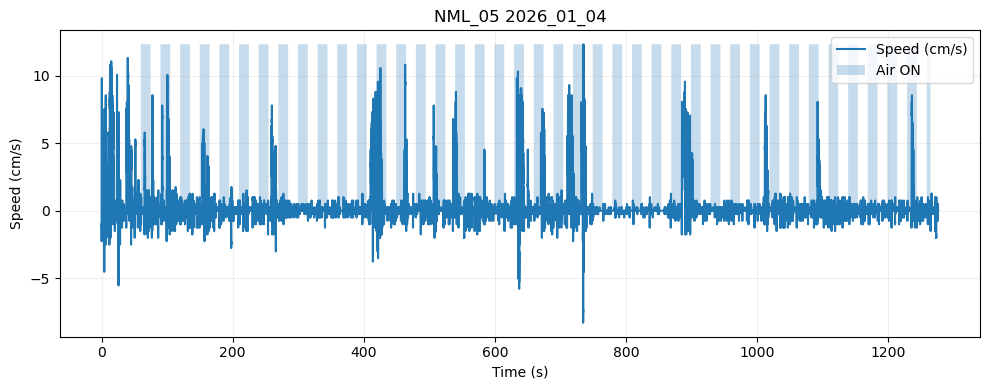

In [13]:
from src.vis.plots import quick_plot_from_h5 as quick_plot

quick_plot(cc_data, "NML_05", "2026_01_04")

<Axes: >

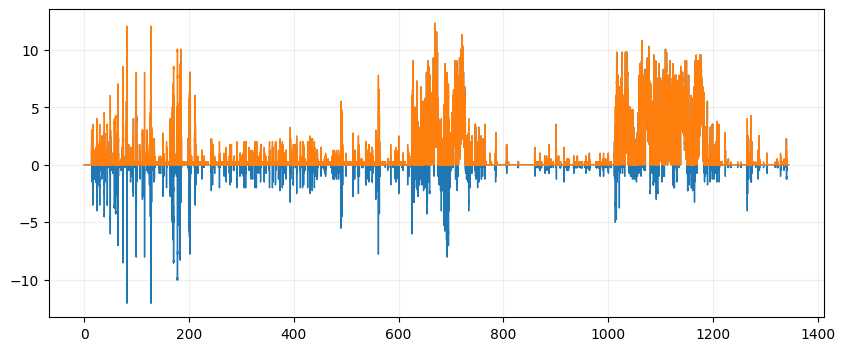

In [29]:
from vis.plots import quick_plot_keys_from_h5 as quick_plotK

quick_plotK(
    "NML_04",
    "2026_01_05",
    ykeys=[
        "speed_net_cms",
        "speed_path_cms"
    ]
)

In [ ]:
from vis.plots import interactive_plot_keys_from_h5

interactive_plot_keys_from_h5(
    "NML_04",
    "2026_01_05",
    ykeys=["speed_path_cms", "air_bin"],
    tlim=(0, 300)
)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'QC: air_raw / air_bin with Air_r (--) and Air_f (:)'}, xlabel='Time (s)', ylabel='Signal (scaled units)'>)

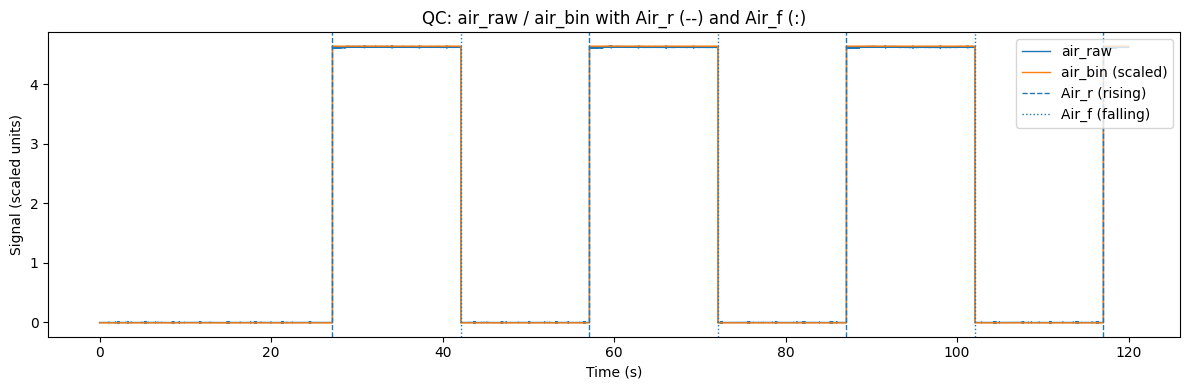

In [61]:
# Load selected keys (variable) from behavior file.
from vis.qc_air_edges import qc_plot_air_edges

b = pdio.load_behavior_h5(
    animal,
    date,
    keys=["fs", "t", "air_raw", "air_bin", "Air_r", "Air_f", "speed_net_cms"]
)

qc_plot_air_edges(b, max_seconds=120, overlay_speed=False, title=None)